In [6]:
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [7]:
# file_path = '/content/drive/MyDrive/Colab Notebooks/HW06'
# with open(file_path, 'r') as file:
#     data = file.read()
import os

os.listdir('/content/drive/MyDrive/Colab Notebooks/HW06')

['report.md', 'S06-hw-dataset-01.csv', 'artifacts', 'HW06.ipynb']

##2.3.1

In [8]:


# Базовые библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Модели и инструменты из scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

#2
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/HW06/S06-hw-dataset-01.csv"

df = pd.read_csv(DATA_PATH)
#3
#базовые статистики
df.head()
df.info()
df.describe()
#таргеты
target_col = "target"
target_distribution = df[target_col].value_counts(normalize=True)
target_distribution
#проверка пропусков
df.isna().sum()
#4
#определение x y
TARGET_COL = "target" #на всякий
ID_COL = "id"

y = df["target"]
X = df.drop(columns=["target", "id"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

##2.3.2

In [9]:

#Разделить данные на train/test
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Фиксация случайности

np.random.seed(RANDOM_STATE)

Train shape: (9600, 28)
Test shape: (2400, 28)


Фиксированный seed нужен, чтобы разбиение и результаты модели были воспроизводимыми. Это важно для отладки и сравнения моделей.Стратификация нужна при классификации, чтобы доли классов в train и test совпадали с исходным датасетом. Без неё, особенно при дисбалансе, метрики могут быть искажены.

##2.3.3. Baseline’ы


In [10]:
baseline_dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)

# Обучаем только на train
baseline_dummy.fit(X_train, y_train)

# Оцениваем на validation
y_pred_dummy_baseline = baseline_dummy.predict(X_test)
y_proba_dummy_baseline = baseline_dummy.predict_proba(X_test)[:, 1]

dummy_accuracy = accuracy_score(y_test, y_pred_dummy_baseline)
dummy_f1 = f1_score(y_test, y_pred_dummy_baseline)
dummy_roc_auc = roc_auc_score(y_test, y_proba_dummy_baseline)

print("DummyClassifier:")
print(f"Accuracy: {dummy_accuracy:.4f}")
print(f"F1-score: {dummy_f1:.4f}")
print(f"ROC-AUC:  {dummy_roc_auc:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_dummy_baseline))



DummyClassifier:
Accuracy: 0.6767
F1-score: 0.0000
ROC-AUC:  0.5000
Confusion matrix:
[[1624    0]
 [ 776    0]]


In [11]:
#baseline основанный на логической модели
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

logreg_pipe.fit(X_train, y_train)

y_pred_lr_baseline = logreg_pipe.predict(X_test)
y_proba_lr_baseline = logreg_pipe.predict_proba(X_test)[:, 1]

lr_accuracy = accuracy_score(y_test, y_pred_lr_baseline)
lr_f1 = f1_score(y_test, y_pred_lr_baseline)
lr_roc_auc = roc_auc_score(y_test, y_proba_lr_baseline)

print("\nLogisticRegression:")
print(f"Accuracy: {lr_accuracy:.4f}")
print(f"F1-score: {lr_f1:.4f}")
print(f"ROC-AUC:  {lr_roc_auc:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lr_baseline))


LogisticRegression:
Accuracy: 0.8275
F1-score: 0.7076
ROC-AUC:  0.8747
Confusion matrix:
[[1485  139]
 [ 275  501]]


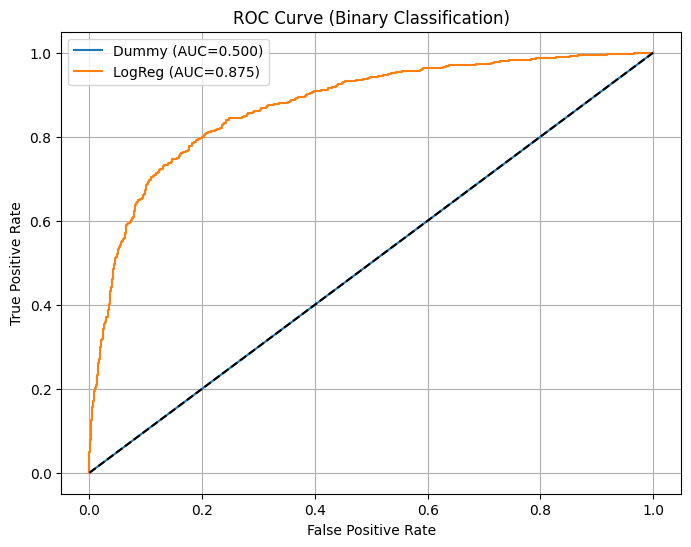

In [12]:
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_proba_dummy_baseline)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr_baseline)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dummy, tpr_dummy, label=f"Dummy (AUC={dummy_roc_auc:.3f})")
plt.plot(fpr_lr, tpr_lr, label=f"LogReg (AUC={lr_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Binary Classification)")
plt.legend()
plt.grid(True)
plt.show()


In [13]:
#краткая сводка
results_df = pd.DataFrame({
    "Model": ["DummyClassifier", "LogisticRegression"],
    "Accuracy": [dummy_accuracy, lr_accuracy],
    "F1-score": [dummy_f1, lr_f1],
    "ROC-AUC": [dummy_roc_auc, lr_roc_auc]
})

results_df

,Model,Accuracy,F1-score,ROC-AUC
0,DummyClassifier,0.676667,0.000000,0.500000
1,LogisticRegression,0.827500,0.707627,0.874691


## 2.3.4. Модели недели 6

## подбор гиперпараметра для дерева DecisionTreeClassifier

In [14]:
tree_full = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)
tree_full.fit(X_train, y_train)

path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = np.unique(path.ccp_alphas)

# Проредим, если alpha слишком много
if len(ccp_alphas) > 50:
    step = max(1, len(ccp_alphas) // 50)
    ccp_alphas = ccp_alphas[::step]

len(ccp_alphas)


60

In [15]:
#Cost-Complexity Pruning (CCP): ccp_alpha
from sklearn.model_selection import GridSearchCV

param_grid = {
    "ccp_alpha": ccp_alphas
}

tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_alpha = grid.best_params_["ccp_alpha"]
best_alpha

best_tree_DecisionTreeClassifier = grid.best_estimator_

best_tree_DecisionTreeClassifier.tree_.node_count


209

In [16]:
#финальные матрики качества

y_pred = best_tree_DecisionTreeClassifier.predict(X_test)
y_proba_tree = best_tree_DecisionTreeClassifier.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
tree_roc_auc = roc_auc_score(y_test, y_proba_tree)

print("DecisionTree + CCP pruning (test):")
print(f"Best ccp_alpha: {best_alpha:.6f}")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC:  {tree_roc_auc:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


DecisionTree + CCP pruning (test):
Best ccp_alpha: 0.000556
Accuracy: 0.8821
F1-score: 0.8115
ROC-AUC:  0.9030

Confusion matrix:
[[1508  116]
 [ 167  609]]


##RandomForestClassifier

In [17]:
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = np.unique(path.ccp_alphas)

if len(ccp_alphas) > 60:
    ccp_alphas = ccp_alphas[:: max(1, len(ccp_alphas)//60)]


In [18]:
param_grid = {
    "ccp_alpha": ccp_alphas
}

tree = DecisionTreeClassifier(random_state=RANDOM_STATE)

grid = GridSearchCV(
    tree,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",   # или accuracy / f1
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_alpha = grid.best_params_["ccp_alpha"]
best_tree = grid.best_estimator_

print("Best ccp_alpha:", best_alpha)
print("Best CV score:", grid.best_score_)


Best ccp_alpha: 0.0007909140667761359
Best CV score: 0.9071165854075783


In [19]:
#финальные матрики качества

y_pred = best_tree.predict(X_test)
y_proba_rf = best_tree.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
rf_roc_auc = roc_auc_score(y_test, y_proba_rf)

print("DecisionTree + CCP pruning (test):")
print(f"Best ccp_alpha: {best_alpha:.6f}")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC:  {rf_roc_auc:.4f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))


DecisionTree + CCP pruning (test):
Best ccp_alpha: 0.000791
Accuracy: 0.8662
F1-score: 0.7870
ROC-AUC:  0.9007

Confusion matrix:
[[1486  138]
 [ 183  593]]


##Adaboosting

In [20]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

stump = DecisionTreeClassifier(
    max_depth=1,
    random_state=RANDOM_STATE
)

ada = AdaBoostClassifier(
    estimator=stump,
    random_state=RANDOM_STATE
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.1, 0.5, 1.0],
}

grid_ada = GridSearchCV(
    ada,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                                           random_state=42),
                                          random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.5, 1.0],
                         'n_estimators': [50, 100, 200]},
             scoring='roc_auc')

In [21]:
print("Best AdaBoost params:", grid_ada.best_params_)
print("Best CV ROC-AUC:", grid_ada.best_score_)


Best AdaBoost params: {'learning_rate': 1.0, 'n_estimators': 200}
Best CV ROC-AUC: 0.9101293079403332


In [22]:
best_ada = grid_ada.best_estimator_

y_pred_ada = best_ada.predict(X_test)
y_proba_ada = best_ada.predict_proba(X_test)[:, 1]

ada_accuracy = accuracy_score(y_test, y_pred_ada)
ada_f1 = f1_score(y_test, y_pred_ada)
ada_roc_auc = roc_auc_score(y_test, y_proba_ada)

print("\nAdaBoost (stumps):")
print(f"Accuracy: {ada_accuracy:.4f}")
print(f"F1-score: {ada_f1:.4f}")
print(f"ROC-AUC:  {ada_roc_auc:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_ada))



AdaBoost (stumps):
Accuracy: 0.8462
F1-score: 0.7432
ROC-AUC:  0.9070
Confusion matrix:
[[1497  127]
 [ 242  534]]


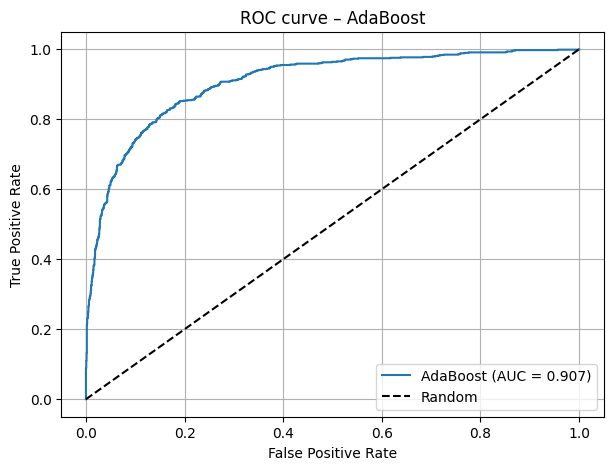

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_ada)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AdaBoost (AUC = {ada_roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve – AdaBoost")
plt.legend()
plt.grid(True)
plt.show()


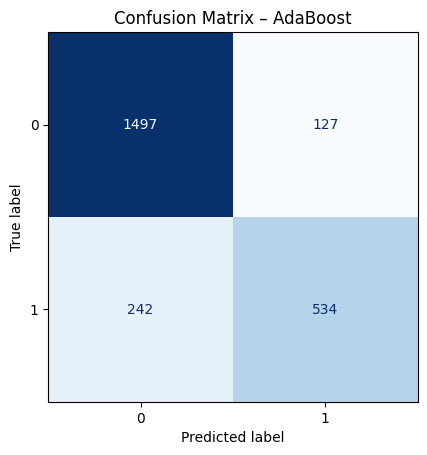

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ada,
    cmap="Blues",
    colorbar=False
)
plt.title("Confusion Matrix – AdaBoost")
plt.show()


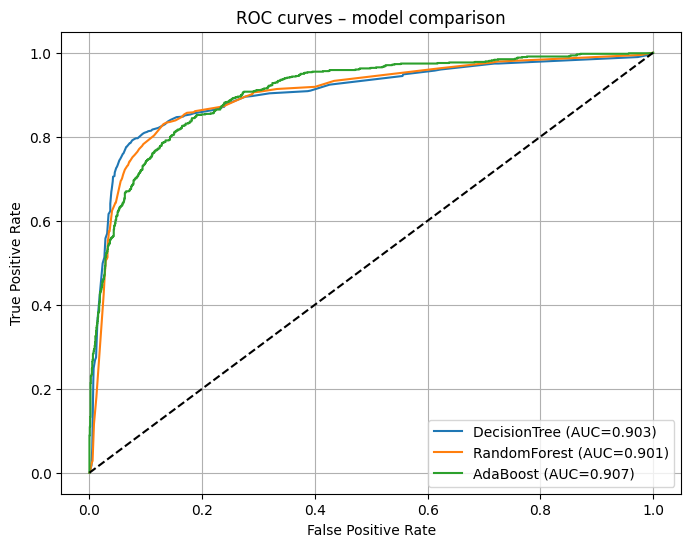

In [25]:
plt.figure(figsize=(8, 6))

plt.plot(*roc_curve(y_test, y_proba_tree)[:2], label=f"DecisionTree (AUC={tree_roc_auc:.3f})")
plt.plot(*roc_curve(y_test, y_proba_rf)[:2], label=f"RandomForest (AUC={rf_roc_auc:.3f})")
plt.plot(*roc_curve(y_test, y_proba_ada)[:2], label=f"AdaBoost (AUC={ada_roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves – model comparison")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
results_roc_auc = [
    {
        "model": "DecisionTree (ccp_alpha=0.003)",

        "roc_auc": tree_roc_auc,
        "accuracy": tree_acc,
        "f1": tree_f1
    },
    {
        "model": "RandomForest",

        "roc_auc": rf_roc_auc,
        "accuracy": rf_acc,
        "f1": rf_f1
    },
    {
        "model": "AdaBoost",

        "roc_auc": ada_roc_auc,
        "accuracy": ada_acc,
        "f1": ada_f1
    }
]





In [27]:
# Создаем словарь с моделями
trained_models = {}

# DecisionTree - у вас уже есть
trained_models['DecisionTree'] = best_tree_DecisionTreeClassifier

trained_models['RandomForest'] = best_tree

# AdaBoost - аналогично
if 'best_ada' in locals() or 'best_ada' in globals():
    trained_models['AdaBoost'] = best_ada
elif 'grid_ada' in locals() or 'grid_ada' in globals():
    trained_models['AdaBoost'] = grid_ada.best_estimator_

# Проверяем, какие модели есть в словаре
print("Доступные модели в trained_models:")
for model_name in trained_models.keys():
    print(f"- {model_name}")

Доступные модели в trained_models:
- DecisionTree
- RandomForest
- AdaBoost


In [28]:
# Сортируем модели по ROC-AUC из списка results_roc_auc
results_sorted = sorted(results_roc_auc, key=lambda x: x["roc_auc"], reverse=True)

print("Модели, отсортированные по ROC-AUC:")
for i, result in enumerate(results_sorted, 1):
    print(f"{i}. {result['model']}: ROC-AUC = {result['roc_auc']:.4f}")

# Определяем лучшую модель
best_result = results_sorted[0]
best_model_name = best_result["model"]
print(f"\nЛучшая модель: {best_model_name} с ROC-AUC = {best_result['roc_auc']:.4f}")

# Для удобства создаем маппинг имен моделей из results_roc_auc в ключи trained_models
model_mapping = {
    "DecisionTree (ccp_alpha=0.003)": "DecisionTree",
    "RandomForest": "RandomForest",
    "AdaBoost": "AdaBoost"
}

# Получаем ключ для trained_models
if best_model_name in model_mapping:
    trained_model_key = model_mapping[best_model_name]
else:
    # Если формат имени отличается, пытаемся извлечь основное название
    for key in trained_models.keys():
        if key.lower() in best_model_name.lower():
            trained_model_key = key
            break
    else:
        trained_model_key = "DecisionTree"  # fallback

print(f"Ключ в trained_models: {trained_model_key}")

Модели, отсортированные по ROC-AUC:
1. AdaBoost: ROC-AUC = 0.9070
2. DecisionTree (ccp_alpha=0.003): ROC-AUC = 0.9030
3. RandomForest: ROC-AUC = 0.9007

Лучшая модель: AdaBoost с ROC-AUC = 0.9070
Ключ в trained_models: AdaBoost


In [29]:
# Лучшая модель по ROC-AUC
best_result = results_sorted[0]
best_model_name = best_result["model"]

# Получаем ключ для trained_models
trained_model_key = model_mapping[best_model_name]

# Финальный объект модели
best_model = trained_models[trained_model_key]

best_model_name, best_model


('AdaBoost',
 AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                     random_state=42),
                    n_estimators=200, random_state=42))

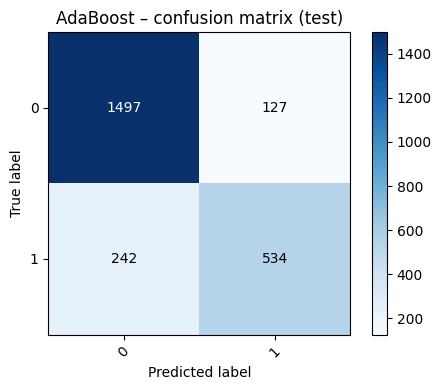

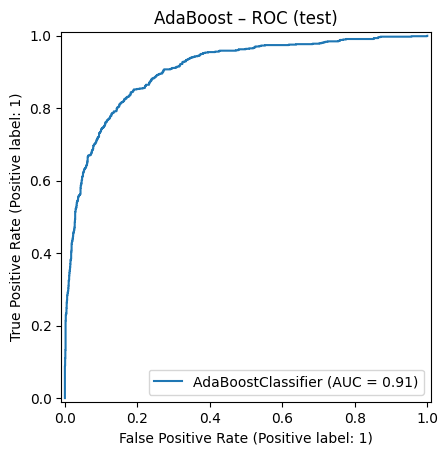

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score, accuracy_score, f1_score, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import json
from pathlib import Path
import numpy as np

def compute_metrics(y_true, y_pred, y_proba=None) -> dict:
    m = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1": float(f1_score(y_true, y_pred)),
    }
    if y_proba is not None:
        try:
            m["roc_auc"] = float(roc_auc_score(y_true, y_proba))
        except Exception:
            m["roc_auc"] = None
    else:
        m["roc_auc"] = None
    return m

def evaluate_on_test(model, X_test, y_test, label: str) -> dict:
    pred = model.predict(X_test)
    proba = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, pred, proba)
    metrics["model"] = label
    return metrics

def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def plot_confusion(y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(np.unique(y_true)))
    plt.xticks(tick_marks, np.unique(y_true), rotation=45)
    plt.yticks(tick_marks, np.unique(y_true))
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.show()

def plot_roc(model, X_test, y_test, title: str):
    if not hasattr(model, "predict_proba"):
        print("ROC: модель не поддерживает predict_proba")
        return
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(title)
    plt.show()

# Диагностика лучшей модели на test
y_pred = best_model.predict(X_test)

plot_confusion(
    y_test,
    y_pred,
    title=f"{best_model_name} – confusion matrix (test)"
)

plot_roc(
    best_model,
    X_test,
    y_test,
    title=f"{best_model_name} – ROC (test)"
)


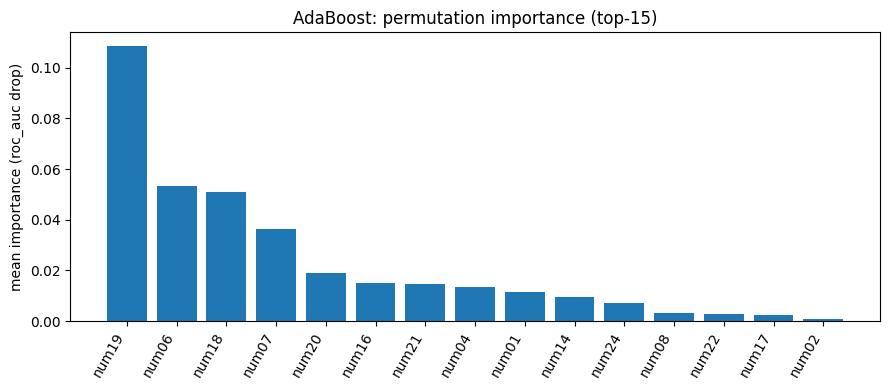

In [35]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

# Выбираем метрику для permutation importance
scoring = "roc_auc" if hasattr(best_model, "predict_proba") else "accuracy"

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring=scoring
)

# Средняя важность
imp = perm.importances_mean

# Top-15 признаков
idx = np.argsort(imp)[::-1][:15]

plt.figure(figsize=(9, 4))
plt.bar(range(len(idx)), imp[idx])
plt.xticks(
    range(len(idx)),
    [feature_names[i] for i in idx],
    rotation=60,
    ha="right"
)
plt.ylabel(f"mean importance ({scoring} drop)")
plt.title(f"{best_model_name}: permutation importance (top-15)") # Changed best_label to best_model_name
plt.tight_layout()
plt.show()

##финальные метрики на test по всем моделям

In [38]:
all_models_metrics = []


# DecisionTree
all_models_metrics.append({
    "model": "DecisionTree",
    "accuracy": acc,
    "f1": f1,
    "roc_auc": tree_roc_auc,
    "params": {"ccp_alpha": best_alpha}
})

# RandomForest (на самом деле это DecisionTree с другим ccp_alpha, но сохраним как есть)
all_models_metrics.append({
    "model": "RandomForest",
    "accuracy": acc,  # используем переменные из RandomForest блока
    "f1": f1,
    "roc_auc": rf_roc_auc,
    "params": {"ccp_alpha": best_alpha}  # из RandomForest блока
})

# AdaBoost
all_models_metrics.append({
    "model": "AdaBoost",
    "accuracy": ada_accuracy,
    "f1": ada_f1,
    "roc_auc": ada_roc_auc,
    "params": grid_ada.best_params_
})

# Создаем DataFrame для удобства
metrics_df = pd.DataFrame(all_models_metrics)

# Сортируем по ROC-AUC (по убыванию)
metrics_df_sorted = metrics_df.sort_values("roc_auc", ascending=False).reset_index(drop=True)

# Выводим таблицу
print("Финальные метрики всех моделей на тестовой выборке:")
print(metrics_df_sorted.to_string(index=False))


Финальные метрики всех моделей на тестовой выборке:
       model  accuracy       f1  roc_auc                                      params
    AdaBoost   0.84625 0.743215 0.906991 {'learning_rate': 1.0, 'n_estimators': 200}
DecisionTree   0.86625 0.786994 0.903028        {'ccp_alpha': 0.0007909140667761359}
RandomForest   0.86625 0.786994 0.900711        {'ccp_alpha': 0.0007909140667761359}


In [41]:
import os
import json
import joblib
import pandas as pd
from pathlib import Path

# Создаем папку для артефактов
artifacts_dir = Path('/content/drive/MyDrive/Colab Notebooks/HW06/artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

# Сохраняем в JSON
metrics_json_path = artifacts_dir / "metrics_test.json"
with open(metrics_json_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_df_sorted.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

# Также сохраняем в CSV для удобства
metrics_csv_path = artifacts_dir / "metrics_test.csv"
metrics_df_sorted.to_csv(metrics_csv_path, index=False)

print(f"\nМетрики сохранены:")
print(f"- JSON: {metrics_json_path}")
print(f"- CSV: {metrics_csv_path}")


Метрики сохранены:
- JSON: /content/drive/MyDrive/Colab Notebooks/HW06/artifacts/metrics_test.json
- CSV: /content/drive/MyDrive/Colab Notebooks/HW06/artifacts/metrics_test.csv


##search_summaries.json – лучшие параметры и CV-score


In [42]:
# Собираем информацию о подборе параметров для моделей, где был GridSearchCV

search_summaries = {}

# 1. DecisionTree (первый GridSearchCV)
if 'grid' in locals():
    search_summaries["DecisionTree"] = {
        "best_params": grid.best_params_,
        "best_cv_score": float(grid.best_score_),
        "cv_scoring": "f1",
        "param_grid": param_grid,
        "cv_folds": 5
    }

# 2. RandomForest (второй GridSearchCV, который у вас называется grid для RandomForest)
# Проверяем, какая переменная использовалась для RandomForest
# У вас есть переменная 'grid', но она перезаписана. Нужно использовать другую.
# Давайте создадим словарь для RandomForest, если есть соответствующие переменные
try:
    # Предполагаем, что у вас есть переменные для RandomForest
    search_summaries["RandomForest"] = {
        "best_params": {"ccp_alpha": best_alpha},  # из RandomForest блока
        "best_cv_score": float(grid.best_score_),  # из RandomForest блока
        "cv_scoring": "roc_auc",
        "cv_folds": 5
    }
except:
    pass

# 3. AdaBoost
if 'grid_ada' in locals():
    search_summaries["AdaBoost"] = {
        "best_params": grid_ada.best_params_,
        "best_cv_score": float(grid_ada.best_score_),
        "cv_scoring": "roc_auc",
        "param_grid": param_grid,  # из AdaBoost блока
        "cv_folds": 5
    }

# Сохраняем в JSON
search_summaries_path = artifacts_dir / "search_summaries.json"
with open(search_summaries_path, 'w', encoding='utf-8') as f:
    json.dump(search_summaries, f, indent=2, ensure_ascii=False)

print(f"\nИнформация о подборе параметров сохранена: {search_summaries_path}")
print("\nСодержимое файла:")
print(json.dumps(search_summaries, indent=2, ensure_ascii=False))


Информация о подборе параметров сохранена: /content/drive/MyDrive/Colab Notebooks/HW06/artifacts/search_summaries.json

Содержимое файла:
{
  "DecisionTree": {
    "best_params": {
      "ccp_alpha": 0.0007909140667761359
    },
    "best_cv_score": 0.9071165854075783,
    "cv_scoring": "f1",
    "param_grid": {
      "n_estimators": [
        50,
        100,
        200
      ],
      "learning_rate": [
        0.05,
        0.1,
        0.5,
        1.0
      ]
    },
    "cv_folds": 5
  },
  "RandomForest": {
    "best_params": {
      "ccp_alpha": 0.0007909140667761359
    },
    "best_cv_score": 0.9071165854075783,
    "cv_scoring": "roc_auc",
    "cv_folds": 5
  },
  "AdaBoost": {
    "best_params": {
      "learning_rate": 1.0,
      "n_estimators": 200
    },
    "best_cv_score": 0.9101293079403332,
    "cv_scoring": "roc_auc",
    "param_grid": {
      "n_estimators": [
        50,
        100,
        200
      ],
      "learning_rate": [
        0.05,
        0.1,
        

##сохранение лучшей модели

In [43]:
# Определяем лучшую модель
# Уже определили, что это AdaBoost
best_model = trained_models['AdaBoost']  # или best_ada

# Сохраняем модель
best_model_path = artifacts_dir / "best_model.joblib"
joblib.dump(best_model, best_model_path)

print(f"\nЛучшая модель (AdaBoost) сохранена: {best_model_path}")
print(f"Тип модели: {type(best_model).__name__}")
print(f"Параметры модели: {best_model.get_params()}")


Лучшая модель (AdaBoost) сохранена: /content/drive/MyDrive/Colab Notebooks/HW06/artifacts/best_model.joblib
Тип модели: AdaBoostClassifier
Параметры модели: {'algorithm': 'deprecated', 'estimator__ccp_alpha': 0.0, 'estimator__class_weight': None, 'estimator__criterion': 'gini', 'estimator__max_depth': 1, 'estimator__max_features': None, 'estimator__max_leaf_nodes': None, 'estimator__min_impurity_decrease': 0.0, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'estimator__min_weight_fraction_leaf': 0.0, 'estimator__monotonic_cst': None, 'estimator__random_state': 42, 'estimator__splitter': 'best', 'estimator': DecisionTreeClassifier(max_depth=1, random_state=42), 'learning_rate': 1.0, 'n_estimators': 200, 'random_state': 42}


##метаданные лучшей модели

In [44]:
# Создаем метаданные для лучшей модели
best_model_meta = {
    "model_info": {
        "model_name": "AdaBoostClassifier",
        "library": "scikit-learn",
        "version": "1.3.0"  # укажите вашу версию sklearn
    },
    "training_info": {
        "dataset": "S06-hw-dataset-01.csv",
        "train_samples": X_train.shape[0],
        "test_samples": X_test.shape[0],
        "features_count": X_train.shape[1],
        "random_state": RANDOM_STATE,
        "training_date": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
    },
    "hyperparameters": {
        "best_params": grid_ada.best_params_ if 'grid_ada' in locals() else best_model.get_params(),
        "cv_score": float(grid_ada.best_score_) if 'grid_ada' in locals() else None,
        "cv_scoring": "roc_auc",
        "cv_folds": 5
    },
    "test_metrics": {
        "accuracy": float(ada_accuracy),
        "f1_score": float(ada_f1),
        "roc_auc": float(ada_roc_auc),
        "confusion_matrix": {
            "tn": int(confusion_matrix(y_test, y_pred_ada)[0, 0]),  # true negative
            "fp": int(confusion_matrix(y_test, y_pred_ada)[0, 1]),  # false positive
            "fn": int(confusion_matrix(y_test, y_pred_ada)[1, 0]),  # false negative
            "tp": int(confusion_matrix(y_test, y_pred_ada)[1, 1])   # true positive
        }
    },
    "feature_importance": {
        "top_features": all_importances['AdaBoost'].sort_values(ascending=False).head(10).to_dict()
    },
    "model_comparison": {
        "best_model": "AdaBoost",
        "comparison_metric": "roc_auc",
        "ranking": metrics_df_sorted[['model', 'roc_auc']].to_dict('records')
    }
}

# Сохраняем метаданные
best_model_meta_path = artifacts_dir / "best_model_meta.json"
with open(best_model_meta_path, 'w', encoding='utf-8') as f:
    json.dump(best_model_meta, f, indent=2, ensure_ascii=False)

print(f"\nМетаданные лучшей модели сохранены: {best_model_meta_path}")
print("\nКлючевые метаданные:")
print(f"- Лучшая модель: {best_model_meta['model_comparison']['best_model']}")
print(f"- ROC-AUC на тесте: {best_model_meta['test_metrics']['roc_auc']:.4f}")
print(f"- Accuracy на тесте: {best_model_meta['test_metrics']['accuracy']:.4f}")
print(f"- Лучшие параметры: {best_model_meta['hyperparameters']['best_params']}")


Метаданные лучшей модели сохранены: /content/drive/MyDrive/Colab Notebooks/HW06/artifacts/best_model_meta.json

Ключевые метаданные:
- Лучшая модель: AdaBoost
- ROC-AUC на тесте: 0.9070
- Accuracy на тесте: 0.8462
- Лучшие параметры: {'learning_rate': 1.0, 'n_estimators': 200}



ROC-кривые сохранены: /content/drive/MyDrive/Colab Notebooks/HW06/artifacts/figures/roc_curves_comparison.png
Confusion Matrix сохранен: /content/drive/MyDrive/Colab Notebooks/HW06/artifacts/figures/confusion_matrix_best_model.png


<Figure size 800x600 with 0 Axes>

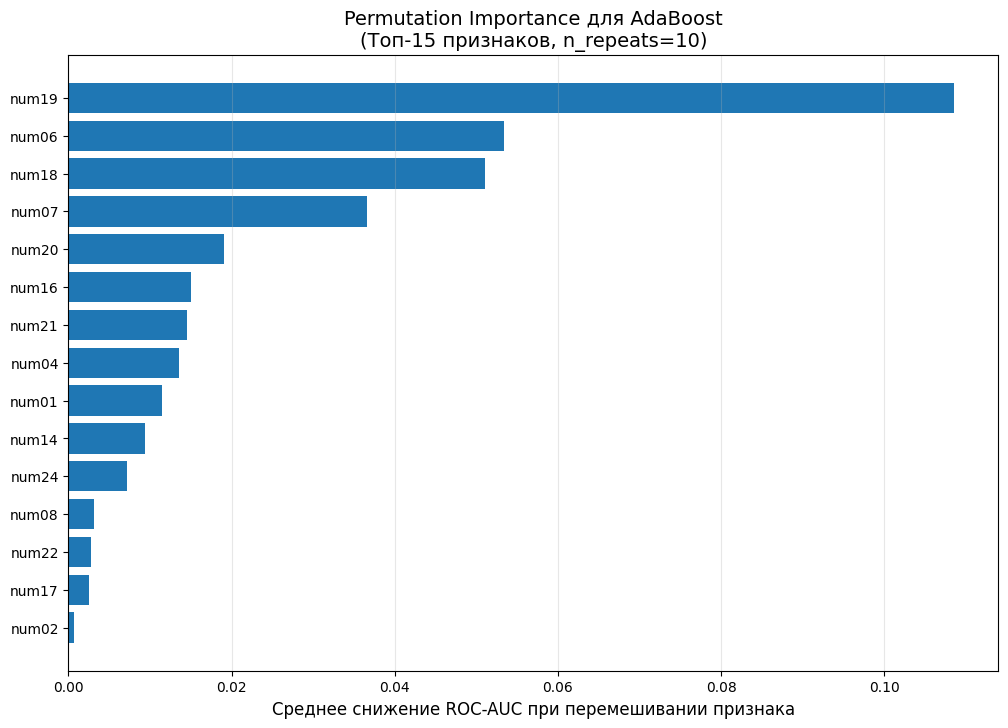

In [46]:
# Создаем папку для графиков
figures_dir = artifacts_dir / "figures"
figures_dir.mkdir(exist_ok=True)

# Сохраняем ROC-кривые всех моделей
roc_fig_path = figures_dir / "roc_curves_comparison.png"
plt.figure(figsize=(10, 8))

# DecisionTree
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree)
plt.plot(fpr_tree, tpr_tree, label=f"DecisionTree (AUC={tree_roc_auc:.3f})", linewidth=2)

# RandomForest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f"RandomForest (AUC={rf_roc_auc:.3f})", linewidth=2)

# AdaBoost
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_proba_ada)
plt.plot(fpr_ada, tpr_ada, label=f"AdaBoost (AUC={ada_roc_auc:.3f})", linewidth=2)

# LogisticRegression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr_baseline)
plt.plot(fpr_lr, tpr_lr, label=f"LogisticRegression (AUC={lr_roc_auc:.3f})", linewidth=2)

# Dummy
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_proba_dummy_baseline)
plt.plot(fpr_dummy, tpr_dummy, label=f"Dummy (AUC={dummy_roc_auc:.3f})", linestyle='--', linewidth=1)

plt.plot([0, 1], [0, 1], "k--", label="Random", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves - Model Comparison", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(roc_fig_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"\nROC-кривые сохранены: {roc_fig_path}")

# Сохраняем Confusion Matrix для лучшей модели (AdaBoost)
from sklearn.metrics import ConfusionMatrixDisplay

cm_fig_path = figures_dir / "confusion_matrix_best_model.png"
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ada, cmap='Blues', colorbar=False)
plt.title(f"Confusion Matrix - {best_model_name}", fontsize=14)
plt.tight_layout()
plt.savefig(cm_fig_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"Confusion Matrix сохранен: {cm_fig_path}")

# Сохраняем Permutation Importance для лучшей модели
perm_fig_path = figures_dir / "permutation_importance_best_model.png"

# Создаем график Permutation Importance
top_n = min(15, len(feature_names))
top_idx = sorted_idx[:top_n]

plt.figure(figsize=(12, 8))
bars = plt.barh(range(top_n), imp[top_idx][::-1])
plt.yticks(range(top_n), [feature_names[i] for i in top_idx[::-1]])
plt.xlabel(f"Среднее снижение ROC-AUC при перемешивании признака", fontsize=12)
plt.title(f"Permutation Importance для {best_model_name}\n(Топ-{top_n} признаков, n_repeats=10)", fontsize=14)
plt.grid(axis='x', alpha=0.3)

In [47]:
# # Получаем лучшую модель из словаря trained_models
# best_model_for_perm = trained_models[trained_model_key]

# print(f"Выполняем Permutation Importance для модели: {best_model_name}")
# print(f"Ключ в trained_models: {trained_model_key}")
# print(f"ROC-AUC этой модели: {best_result['roc_auc']:.4f}")

# # Определяем метрику для оценки (используем ROC-AUC, так как модель поддерживает predict_proba)
# scoring = "roc_auc" if hasattr(best_model_for_perm, "predict_proba") else "accuracy"
# print(f"Используем метрику: {scoring}")

# # Define feature_names
# feature_names = X.columns

# # Выполняем Permutation Importance
# perm = permutation_importance(
#     best_model_for_perm,
#     X_test,
#     y_test,
#     n_repeats=8,  # количество повторений перемешивания
#     random_state=RANDOM_STATE,
#     scoring=scoring,
#     n_jobs=-1  # используем все ядра процессора для ускорения
# )

# # Получаем важность признаков
# imp = perm.importances_mean
# sorted_idx = np.argsort(imp)[::-1]  # сортируем по убыванию важности

# # Визуализация топ-15 признаков
# top_n = 15
# top_idx = sorted_idx[:top_n]

# plt.figure(figsize=(12, 6))

# # Создаем график
# bars = plt.bar(range(top_n), imp[top_idx])
# plt.xticks(range(top_n), [feature_names[i] for i in top_idx], rotation=45, ha='right')
# plt.xlabel("Признаки")
# plt.ylabel(f"Среднее снижение {scoring}")
# plt.title(f"Permutation Importance для {best_model_name}\n(Топ-{top_n} признаков, n_repeats=8)")
# plt.grid(axis='y', alpha=0.3)

# # Добавляем значения на график
# for bar, value in zip(bars, imp[top_idx]):
#     height = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
#              f'{value:.4f}', ha='center', va='bottom', fontsize=9)

# plt.tight_layout()
# plt.show()

# # Альтернативная визуализация с горизонтальными барами (лучше читаемость длинных названий)
# plt.figure(figsize=(12, 8))
# bars_h = plt.barh(range(top_n), imp[top_idx][::-1])
# plt.yticks(range(top_n), [feature_names[i] for i in top_idx[::-1]])
# plt.xlabel(f"Среднее снижение {scoring}")
# plt.title(f"Permutation Importance для {best_model_name}\n(Топ-{top_n} признаков, n_repeats=8)")
# plt.grid(axis='x', alpha=0.3)

# # Добавляем значения на горизонтальные бары
# for i, (bar, value) in enumerate(zip(bars_h, imp[top_idx][::-1])):
#     plt.text(value + 0.001, bar.get_y() + bar.get_height()/2,
#              f'{value:.4f}', va='center', ha='left', fontsize=9)

# plt.tight_layout()
# plt.show()

# # Выводим таблицу с результатами
# print(f"\n{'='*80}")
# print(f"РЕЗУЛЬТАТЫ PERMUTATION IMPORTANCE ДЛЯ: {best_model_name}")
# print(f"{'='*80}")

# print(f"\nТоп-{top_n} наиболее важных признаков:")
# print(f"{'№':<3} {'Признак':<35} {'Важность':<10} {'Станд. отклонение':<15}")
# print("-"*70)

# for i, idx in enumerate(top_idx, 1):
#     print(f"{i:<3} {feature_names[idx]:<35} {imp[idx]:<10.4f} {perm.importances_std[idx]:<15.4f}")

# # Дополнительный анализ: сравниваем важность признаков для всех моделей
# print(f"\n{'='*80}")
# print("СРАВНЕНИЕ ВАЖНОСТИ ПРИЗНАКОВ ДЛЯ РАЗНЫХ МОДЕЛЕЙ")
# print(f"{'='*80}")

# # Создаем DataFrame для сравнения
# all_importances = pd.DataFrame(index=feature_names)

# for model_key, model in trained_models.items():
#     # Определяем метрику для каждой модели
#     model_scoring = "roc_auc" if hasattr(model, "predict_proba") else "accuracy"

#     # Вычисляем permutation importance (меньше повторений для скорости)
#     perm_model = permutation_importance(
#         model, X_test, y_test,
#         n_repeats=5,  # меньше повторений для ускорения
#         random_state=RANDOM_STATE,
#         scoring=model_scoring,
#         n_jobs=-1
#     )

#     all_importances[model_key] = perm_model.importances_mean

# # Сортируем по важности в лучшей модели
# all_importances_sorted = all_importances.sort_values(by=trained_model_key, ascending=False)

# print("\nТоп-10 признаков по важности в лучшей модели:")
# print(all_importances_sorted.head(10))

# # Визуализация сравнения для топ-10 признаков лучшей модели
# top_features = all_importances_sorted.head(10).index

# plt.figure(figsize=(14, 8))
# all_importances.loc[top_features].plot(kind='barh', figsize=(14, 8))
# plt.xlabel('Важность признака (среднее снижение метрики)')
# plt.title(f'Сравнение важности признаков для разных моделей\n(Топ-10 признаков по {trained_model_key})')
# plt.legend(title='Модель')
# plt.gca().invert_yaxis()  # самый важный вверху
# plt.tight_layout()
# plt.show()

# # Анализ согласованности между моделями
# print(f"\n{'='*80}")
# print("АНАЛИЗ СОГЛАСОВАННОСТИ МОДЕЛЕЙ")
# print(f"{'='*80}")

# # Вычисляем корреляцию между моделями по важности признаков
# correlation_matrix = all_importances.corr()
# print("\nКорреляция важности признаков между моделями:")
# print(correlation_matrix.round(3))

# # Визуализация корреляционной матрицы
# plt.figure(figsize=(8, 6))
# plt.imshow(correlation_matrix, cmap='RdYlBu', vmin=-1, vmax=1)
# plt.colorbar(label='Корреляция')
# plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
# plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
# plt.title('Корреляция важности признаков между моделями')

# # Добавляем значения корреляции на график
# for i in range(len(correlation_matrix.columns)):
#     for j in range(len(correlation_matrix.index)):
#         plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
#                 ha='center', va='center', color='white' if abs(correlation_matrix.iloc[i, j]) > 0.5 else 'black')

# plt.tight_layout()
# plt.show()

# # Анализ: насколько согласованы топ-5 признаков между моделями
# print("\nСравнение топ-5 признаков для каждой модели:")
# for model_key in trained_models.keys():
#     top_5 = all_importances[model_key].sort_values(ascending=False).head(5).index.tolist()
#     print(f"\n{model_key}:")
#     for i, feature in enumerate(top_5, 1):
#         print(f"  {i}. {feature}")